# Prédiction de Séries Temporelles avec RNNs

## Chargement et Exploration des Données Fournies

* Chargez le jeu de données temporel assigné.
* Explorez-le : structure, fréquence des données, tendances, saisonnalités (visualisation graphique essentielle), présence de valeurs manquantes.

In [1]:
# --- Importation ---
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from tensorflow.keras import layers, models, optimizers, metrics, callbacks

# --- Configuration ---

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# --- Download dataset ---

# fetch dataset
dataset = fetch_ucirepo(id=235)
df = dataset.data.features

print("Structure des variables selon le fournisseur :\n")
print(dataset.variables)

c:\Users\Iroek\AppData\Local\Programs\Python\Python39\lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Structure des variables selon le fournisseur :

                    name     role         type demographic description units  \
0                   Date  Feature         Date        None        None  None   
1                   Time  Feature  Categorical        None        None  None   
2    Global_active_power  Feature   Continuous        None        None  None   
3  Global_reactive_power  Feature   Continuous        None        None  None   
4                Voltage  Feature   Continuous        None        None  None   
5       Global_intensity  Feature   Continuous        None        None  None   
6         Sub_metering_1  Feature   Continuous        None        None  None   
7         Sub_metering_2  Feature   Continuous        None        None  None   
8         Sub_metering_3  Feature   Continuous        None        None  None   

  missing_values  
0             no  
1             no  
2             no  
3             no  
4             no  
5             no  
6             no  

In [2]:
# --- Exploration initiale ---

print("Dimensions du dataframe brut :")
print(df.shape)

print("Liste des colonnes et types initiaux :")
display(df.dtypes.to_frame("dtype").T)

print("Aperçu du dataframe brut :")
display(df.head())

print("Informations générales :")
display(df.describe(include="all"))

Dimensions du dataframe brut :
(2075259, 9)
Liste des colonnes et types initiaux :


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dtype,object,object,object,object,object,object,object,object,float64


Aperçu du dataframe brut :


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Informations générales :


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2.049280e+06
unique,1442,1440,6534,896,5168,377,153,145,NaN
top,25/11/2010,20:24:00,?,0.000,?,1.000,0.000,0.000,NaN
freq,1440,1442,25979,472786,25979,169406,1840611,1408274,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.458447e+00
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.437154e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000e+01


## Prétraitement Spécifique aux Séries Temporelles (Étapes Clés)

* **Nettoyage** : Gérez les valeurs manquantes (imputation simple ou interpolation, justifiez).
* **Normalisation/Standardisation** : Mettez à l'échelle les valeurs numériques. Discutez de la stratégie : normaliser sur tout le set d'entraînement ou par fenêtre ?
* **Windowing (Fenêtrage)** : Transformez la série temporelle en un jeu de données supervisé en créant des fenêtres glissantes. Chaque fenêtre contiendra une séquence d'entrée (les N valeurs passées) et une cible de sortie (la valeur M pas de temps plus tard - souvent M=1 pour prédire la prochaine valeur). Utilisez `tf.data.Dataset.window` ou des techniques NumPy/Pandas. Justifiez la taille de la fenêtre choisie.
* **Préparation Finale** : Séparez vos données fenêtrées en ensembles d'entraînement, de validation et de test (attention à ne pas mélanger le temps lors de la séparation ! La validation et le test doivent venir après l'entraînement dans le temps).

**Prétraitement Séries Temporelles** :
* Normalisation : Quand et comment normaliser (avant/après windowing, sur quelles données) ?
* Windowing : Comprendre comment créer des fenêtres d'entrée/sortie. Explorer l'utilisation de `tf.data.Dataset.window`, `.flat_map`, `.batch` ou des alternatives NumPy/Pandas. Impact de la taille de la fenêtre.

**Architectures RNN** :
* Limitations SimpleRNN pour dépendances longues.
* Rôle des portes LSTM/GRU.
* Intérêt de Bidirectional (est-ce pertinent pour la prédiction future ? Discutez-en).

**Évaluation Régression** : Comprendre les métriques MSE, MAE, RMSE et leur interprétation. Savoir visualiser et analyser les prédictions vs les valeurs réelles.

In [3]:
# --- Nettoyage des valeurs manquantes et conversion des types ---

# Remplacer les '?' par NaN
df = df.replace("?", np.nan)

# Créer un index temporel à partir de Date + Time
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

# Mettre Datetime en index
df = df.set_index("Datetime").sort_index()

# Supprimer les colonnes texte initiales
df = df.drop(columns=["Date", "Time"])

# Colonnes numériques du dataset original
cols_to_fix = ["Global_active_power","Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]

# Conversion en numérique
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Afficher les données après transformation ---

print("Types après conversion :")
display(df.dtypes.to_frame("dtype").T)

print("Valeurs manquantes avant interpolation :")
print(df.isna().sum())

# --- Réduction du volume de données ---

# Le dataset original est à la minute.
# Pour limiter le temps d'entraînement, on le rééchantillonne à l'heure.
df_hourly = df.resample("h").mean()

# Interpolation pour combler les valeurs manquantes
df_hourly[cols_to_fix] = df_hourly[cols_to_fix].interpolate(method="linear")

# Suppression des éventuelles valeurs manquantes restantes
df_hourly = df_hourly.dropna()

print("Dimensions avant rééchantillonnage :", df.shape)
print("Dimensions après rééchantillonnage horaire :", df_hourly.shape)

display(df_hourly.head())

# --- Création des variables temporelles ---

df_hourly["hour"] = df_hourly.index.hour
df_hourly["dayofweek"] = df_hourly.index.dayofweek
df_hourly["month"] = df_hourly.index.month
df_hourly["dayofyear"] = df_hourly.index.dayofyear
df_hourly["is_weekend"] = (df_hourly["dayofweek"] >= 5).astype(int)

# Encodage cyclique de l'heure
df_hourly["hour_sin"] = np.sin(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["hour_cos"] = np.cos(2 * np.pi * df_hourly["hour"] / 24)

# Encodage cyclique du jour de semaine
df_hourly["dow_sin"] = np.sin(2 * np.pi * df_hourly["dayofweek"] / 7)
df_hourly["dow_cos"] = np.cos(2 * np.pi * df_hourly["dayofweek"] / 7)

# Encodage cyclique du mois
df_hourly["month_sin"] = np.sin(2 * np.pi * df_hourly["month"] / 12)
df_hourly["month_cos"] = np.cos(2 * np.pi * df_hourly["month"] / 12)

display(df_hourly.head())

Types après conversion :


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dtype,float64,float64,float64,float64,float64,float64,float64


Valeurs manquantes avant interpolation :
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
Dimensions avant rééchantillonnage : (2075259, 7)
Dimensions après rééchantillonnage horaire : (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,month,dayofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
Datetime,,,,,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,350,1,-0.965926,-2.588190e-01,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,350,1,-1.000000,-1.836970e-16,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,350,1,-0.965926,2.588190e-01,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,350,1,-0.866025,5.000000e-01,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,350,1,-0.707107,7.071068e-01,-0.974928,-0.222521,-2.449294e-16,1.0


In [4]:
# --- Dataset final utilisé pour les modèles ---
data_df = df_hourly.copy()

# Variable cible
target_col = "Global_active_power"
target_index = data_df.columns.get_loc(target_col)

print("Variable cible :", target_col)
print("Index de la variable cible :", target_index)
print("Colonnes utilisées par le modèle :")
print(list(data_df.columns))

# --- Split chronologique ---
n = len(data_df)

train_df = data_df.iloc[:int(n * 0.70)]
val_df = data_df.iloc[int(n * 0.70):int(n * 0.85)]
test_df = data_df.iloc[int(n * 0.85):]

print("Train :", train_df.shape)
print("Validation :", val_df.shape)
print("Test :", test_df.shape)

# --- Normalisation ---
# On ajuste le scaler uniquement sur le train pour éviter le data leakage.
scaler = StandardScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

# --- Windowing ---
def create_windowed_dataset(data, window_size, batch_size, index, shuffle=False):
    data = data.astype(np.float32)
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data[:-1],
        targets=data[window_size:, index],
        sequence_length=window_size,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=batch_size
    )
    return ds.prefetch(tf.data.AUTOTUNE)


WINDOW_SIZE = 24
BATCH_SIZE = 32

def count_batches(data_length, window_size, batch_size):
    n_windows = max(data_length - window_size, 0)
    return int(np.ceil(n_windows / batch_size)) if n_windows else 0

train_ds = create_windowed_dataset(train_scaled, WINDOW_SIZE, BATCH_SIZE, target_index)
val_ds = create_windowed_dataset(val_scaled, WINDOW_SIZE, BATCH_SIZE, target_index)
test_ds = create_windowed_dataset(test_scaled, WINDOW_SIZE, BATCH_SIZE, target_index)

print("Nombre de batches train/val/test :",
      count_batches(len(train_scaled), WINDOW_SIZE, BATCH_SIZE),
      count_batches(len(val_scaled), WINDOW_SIZE, BATCH_SIZE),
      count_batches(len(test_scaled), WINDOW_SIZE, BATCH_SIZE))

for x_batch, y_batch in train_ds.take(1):
    input_shape = x_batch.shape[1:]
    print("Forme des entrées :", input_shape)
    print("Forme des sorties :", y_batch.shape)

Variable cible : Global_active_power
Index de la variable cible : 0
Colonnes utilisées par le modèle :
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
Train : (24212, 18)
Validation : (5188, 18)
Test : (5189, 18)
Nombre de batches train/val/test : 756 162 162
Forme des entrées : (24, 18)
Forme des sorties : (32,)


## Modèle basé sur SimpleRNN

**Couche** : tf.keras.layers.SimpleRNN.

**Exploration Architecturale** : Testez et documentez l'impact de :
* Nombre d'unités RNN (units).
* Empilement de couches RNN (utilisation de return_sequences=True).
* Ajout de couches Dense et Dropout après la/les couche(s) RNN.
* (Optionnel) Utilisation de tf.keras.layers.Bidirectional.

**Couche de Sortie** : Une couche Dense avec 1 neurone et pas d'activation (régression linéaire sur la sortie du RNN).


In [5]:
# Métrique RMSE personnalisée
rmse_metric = tf.keras.metrics.RootMeanSquaredError(name="rmse")


def build_simplernn_model(input_shape_model, units=64, dropout_rate=0.2, bidirectional=False):
    inp = layers.Input(shape=input_shape_model)

    RNNLayer = layers.SimpleRNN

    if bidirectional:
        x = layers.Bidirectional(
            RNNLayer(units, return_sequences=True)
        )(inp)
    else:
        x = RNNLayer(units, return_sequences=True)(inp)

    x = layers.Dropout(dropout_rate)(x)

    if bidirectional:
        x = layers.Bidirectional(
            RNNLayer(units // 2, return_sequences=False)
        )(x)
    else:
        x = RNNLayer(units // 2, return_sequences=False)(x)

    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(1, activation=None)(x)

    model_name = "Bidirectional_SimpleRNN_model" if bidirectional else "SimpleRNN_model"
    model = models.Model(inp, out, name=model_name)
    return model


# --- Détermination de la forme d'entrée ---
# train_ds contient (X, y) où X est de forme (batch, window_size, n_features)
input_shape = None
for x_batch, y_batch in train_ds.take(1):
    input_shape = x_batch.shape[1:]
    print("input_shape:", input_shape)
    break

# --- Variante 1 : baseline SimpleRNN ---
simple_rnn_baseline = build_simplernn_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2,
)

simple_rnn_baseline.summary()

# --- Variante 2 : SimpleRNN bidirectionnel ---
simple_rnn_bidirectional = build_simplernn_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2,
    bidirectional=True
)

simple_rnn_bidirectional.summary()

input_shape: (24, 18)


Model: "SimpleRNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 24, 64)         │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505 (37.13 KB)

 Trainable params: 9,505 (37.13 KB)

...

Model: "Bidirectional_SimpleRNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,041 (90.00 KB)

 Trainable params: 23,041 (90.00 KB)

 Non-trainable params: 0 (0.00 B)

## Modèle basé sur LSTM

**Couche** : tf.keras.layers.LSTM.

**Exploration Architecturale** : Testez et documentez l'impact de :
* Nombre d'unités RNN (units).
* Empilement de couches RNN (utilisation de return_sequences=True).
* Ajout de couches Dense et Dropout après la/les couche(s) RNN.
* (Optionnel) Utilisation de tf.keras.layers.Bidirectional.

**Couche de Sortie** : Une couche Dense avec 1 neurone et pas d'activation (régression linéaire sur la sortie du RNN).

In [6]:
# --- Modèle LSTM ---

def build_lstm_model(input_shape_model, units=64, dropout_rate=0.2):
    inp = layers.Input(shape=input_shape_model)

    x = layers.LSTM(units, return_sequences=True)(inp)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.LSTM(units // 2, return_sequences=False)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation=None)(x)

    model = models.Model(inp, out, name="LSTM_model")
    return model


lstm_model = build_lstm_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2
)

lstm_model.summary()

Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,753 (135.75 KB)

 Trainable params: 34,753 (135.75 KB)

 Non-trainable params: 0 (0.00 B)

## Modèle basé sur GRU

**Couche** : tf.keras.layers.GRU.

**Exploration Architecturale** : Testez et documentez l'impact de :
* Nombre d'unités RNN (units).
* Empilement de couches RNN (utilisation de return_sequences=True).
* Ajout de couches Dense et Dropout après la/les couche(s) RNN.
* (Optionnel) Utilisation de tf.keras.layers.Bidirectional.

**Couche de Sortie** : Une couche Dense avec 1 neurone et pas d'activation (régression linéaire sur la sortie du RNN).

In [7]:
# --- Modèle GRU ---

def build_gru_model(input_shape_model, units=64, dropout_rate=0.2):
    inp = layers.Input(shape=input_shape_model)

    x = layers.GRU(units, return_sequences=True)(inp)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.GRU(units // 2, return_sequences=False)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation=None)(x)

    model = models.Model(inp, out, name="GRU_model")
    return model


gru_model = build_gru_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2
)

gru_model.summary()

Model: "GRU_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 24, 64)         │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,625 (104.00 KB)

 Trainable params: 26,625 (104.00 KB)

 Non-trainable params: 0 (0.00 B)

## Entraînement et Compilation

* Compilez chaque modèle testé avec un optimiseur (Adam recommandé), une fonction de perte adaptée à la régression (mse ou mae), et des métriques de régression (mae, rmse).
* Entraînez chaque modèle en utilisant les ensembles d'entraînement et de validation fenêtrés, avec des callbacks (EarlyStopping, ModelCheckpoint).

In [8]:
# --- Compilation commune ---

def compile_model(model):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[
            metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )
    return model


# --- Fonction de callbacks ---

def get_callbacks(model_name):
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    checkpoint = callbacks.ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor="val_loss",
        save_best_only=True
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )

    return [early_stop, reduce_lr, checkpoint]


# --- Entraînement SimpleRNN ---

print("Compilation Simple RNN :")
simple_rnn_baseline = compile_model(simple_rnn_baseline)

history_simple_rnn = simple_rnn_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("simple_rnn"),
    verbose=1
)

# --- Entraînement SimpleRNN bidirectionnel ---

print("Compilation Simple RNN bidirectionnel :")
simple_rnn_bidirectional = compile_model(simple_rnn_bidirectional)

history_simple_rnn_bidirectional = simple_rnn_bidirectional.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("simple_rnn_bidirectional"),
    verbose=1
)

# --- Entraînement LSTM ---

print("Compilation LSTM :")
lstm_model = compile_model(lstm_model)

history_lstm = lstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("lstm"),
    verbose=1
)



# --- Entraînement GRU ---

print("Compilation GRU :")
gru_model = compile_model(gru_model)

history_gru = gru_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("gru"),
    verbose=1
)




Compilation Simple RNN :
Epoch 1/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.7713 - mae: 0.6614 - rmse: 0.8719 - val_loss: 0.4300 - val_mae: 0.4656 - val_rmse: 0.6558 - learning_rate: 0.0010
Epoch 2/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.5330 - mae: 0.5326 - rmse: 0.7285 - val_loss: 0.4028 - val_mae: 0.4543 - val_rmse: 0.6347 - learning_rate: 0.0010
Epoch 3/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4987 - mae: 0.5074 - rmse: 0.7043 - val_loss: 0.4088 - val_mae: 0.4606 - val_rmse: 0.6394 - learning_rate: 0.0010
Epoch 4/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4776 - mae: 0.4945 - rmse: 0.6896 - val_loss: 0.3832 - val_mae: 0.4337 - val_rmse: 0.6190 - learning_rate: 0.0010
Epoch 5/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4611 - mae: 0.4818 - rmse: 0.6775 - val_loss: 0.3735 - val_mae: 0.4336 - val_rmse: 0.6111 - learning_rate: 0.0010
Epoch 6/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4550 - mae: 0.4786 - rmse: 0.6729

## Évaluation Comparative et Analyse

* Évaluez les meilleures variantes de chaque type de RNN (`SimpleRNN`, `LSTM`, `GRU`) sur l'ensemble de **test** fenêtré.
* Comparez leurs performances (MSE, MAE, RMSE).
* **Visualisez les prédictions** : Tracez les valeurs réelles et les prédictions de vos meilleurs modèles sur une portion de l'ensemble de test pour comparer visuellement leur qualité.
* Analysez les résultats :
  * Quelle architecture RNN (`SimpleRNN`, `LSTM`, `GRU`) a le mieux fonctionné pour cette série temporelle ?
  * Pourquoi observez-vous ces différences (théorie vs pratique) ?
  * Quelles ont été les limites observées ?
  * Analyse des courbes d'apprentissage.

In [9]:
# --- Évaluation des modèles sur le test ---
simple_rnn_test_metrics = simple_rnn_baseline.evaluate(test_ds, verbose=0)
simple_rnn_bidirectional_test_metrics = simple_rnn_bidirectional.evaluate(test_ds, verbose=0)

lstm_test_metrics = lstm_model.evaluate(test_ds, verbose=0)
gru_test_metrics = gru_model.evaluate(test_ds, verbose=0)

results_comparison = pd.DataFrame(
    [
        ["SimpleRNN", *simple_rnn_test_metrics],
        ["SimpleRNN bidirectionnel", *simple_rnn_bidirectional_test_metrics],
        ["LSTM", *lstm_test_metrics],
        ["GRU", *gru_test_metrics],
    ],
    columns=pd.Index(["Modèle", "Loss/MSE", "MAE", "RMSE"])
)

results_comparison = results_comparison.sort_values("RMSE")

display(results_comparison)

,Modèle,Loss/MSE,MAE,RMSE
2,LSTM,0.241383,0.343779,0.491308
3,GRU,0.241721,0.353372,0.491652
1,SimpleRNN bidirectionnel,0.253344,0.345801,0.503333
0,SimpleRNN,0.264066,0.349322,0.513873


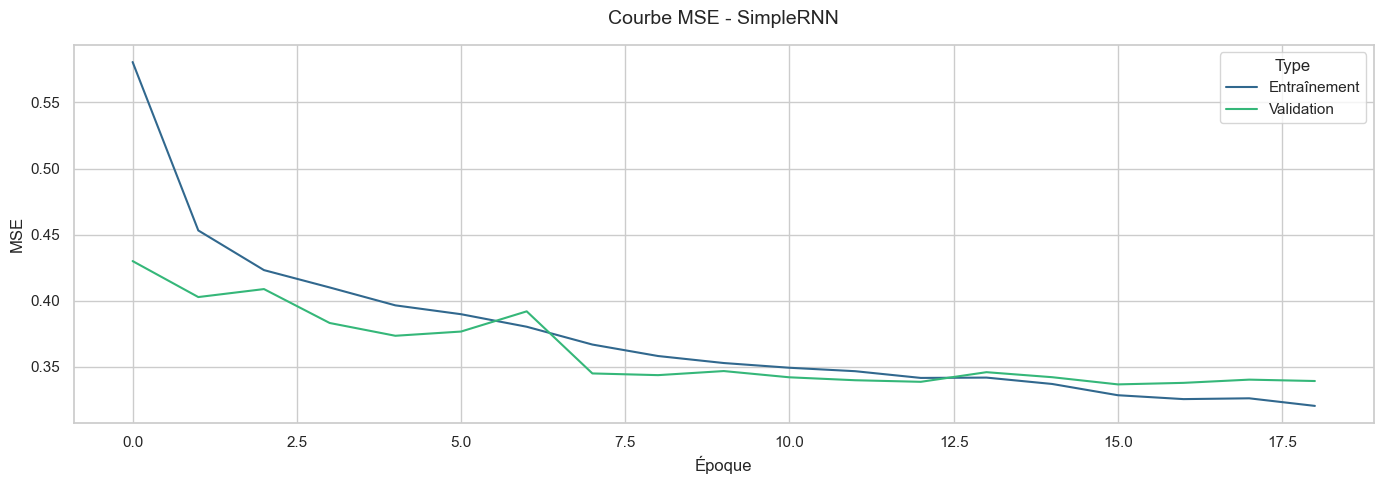

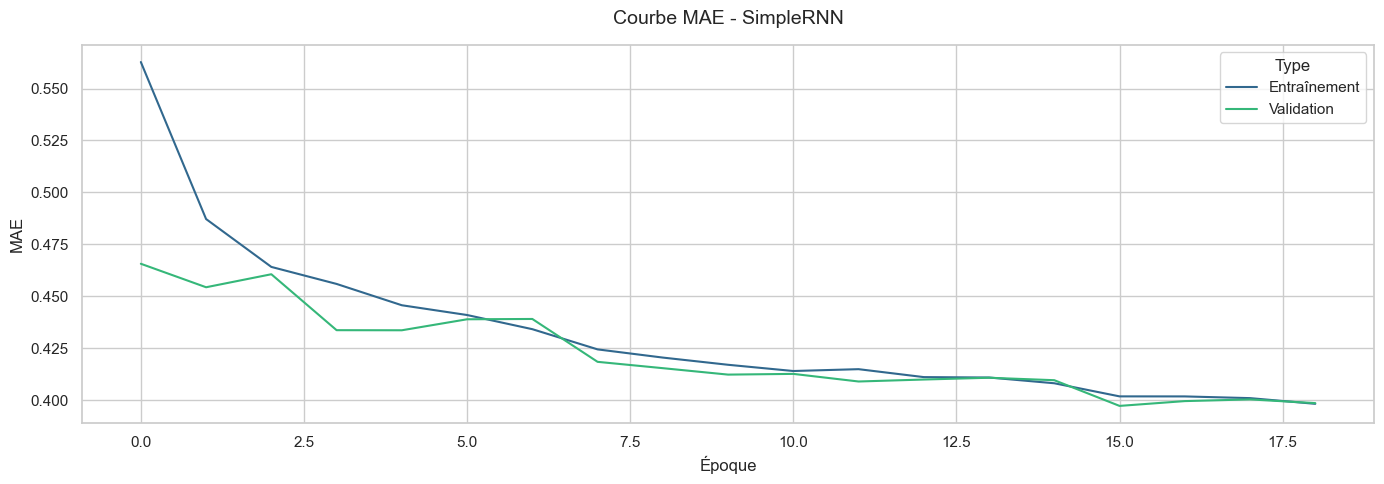

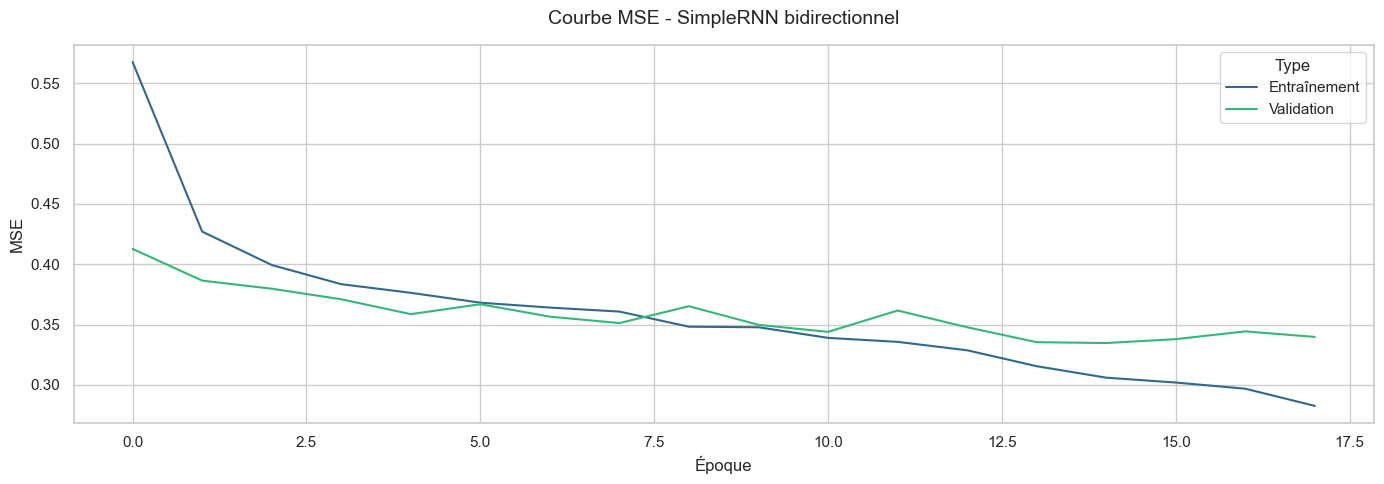

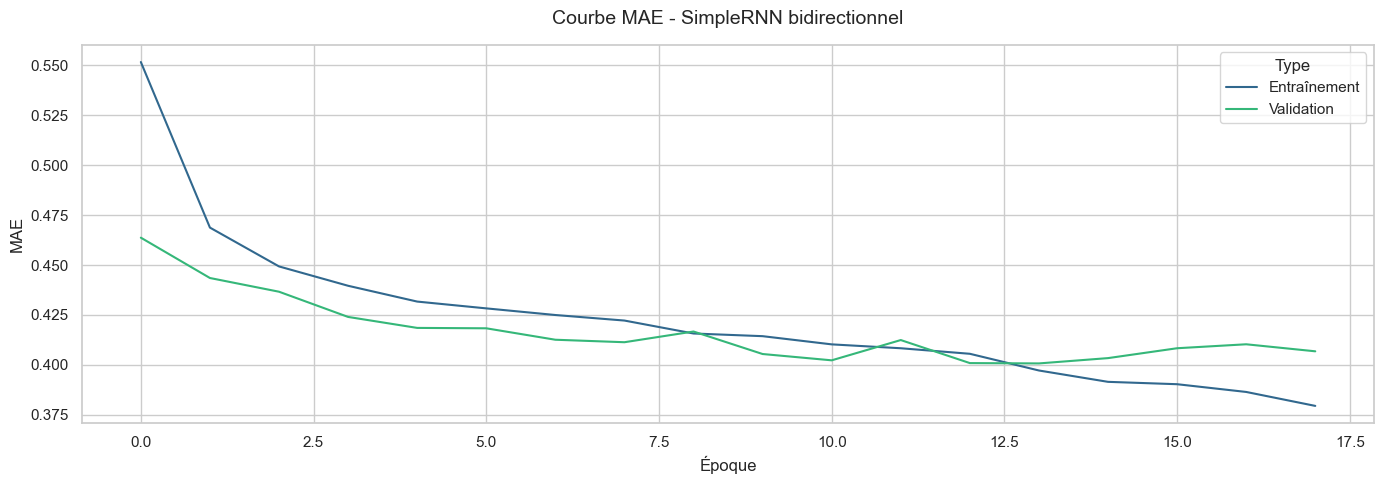

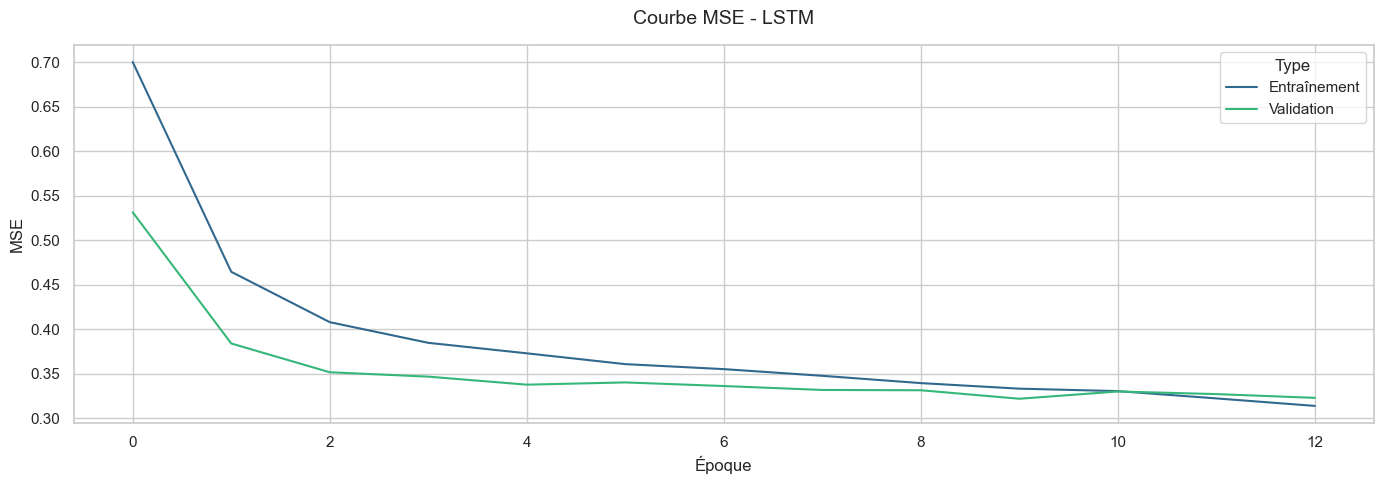

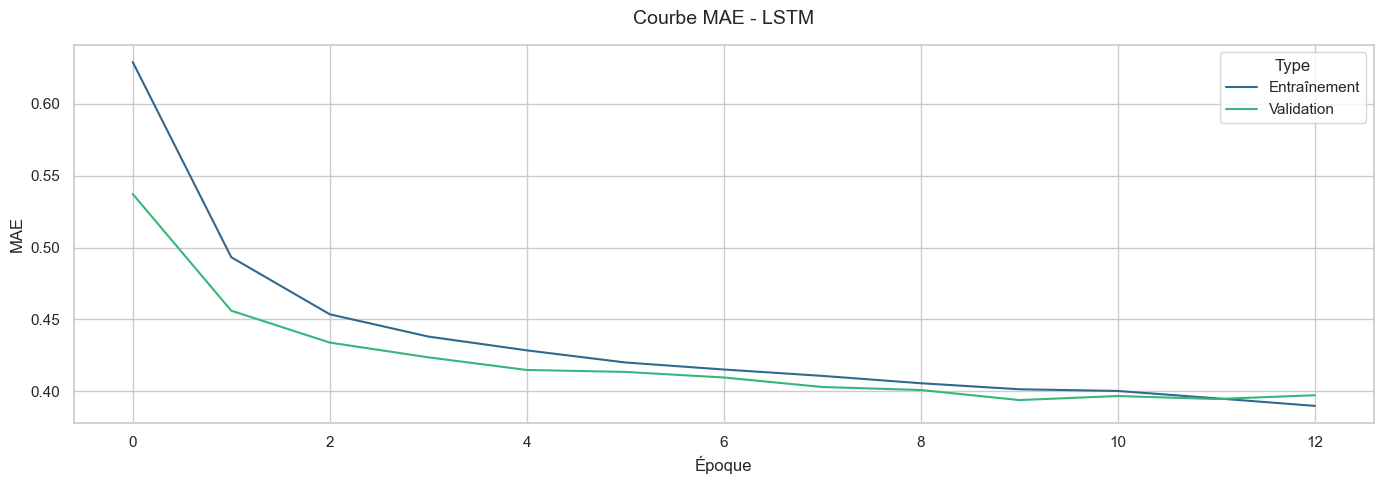

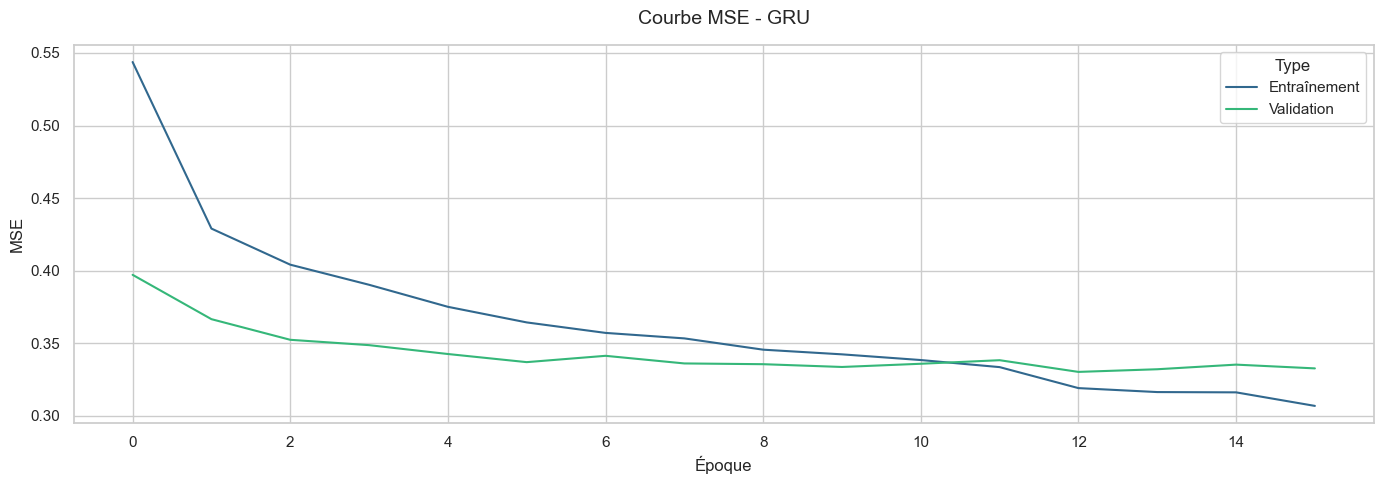

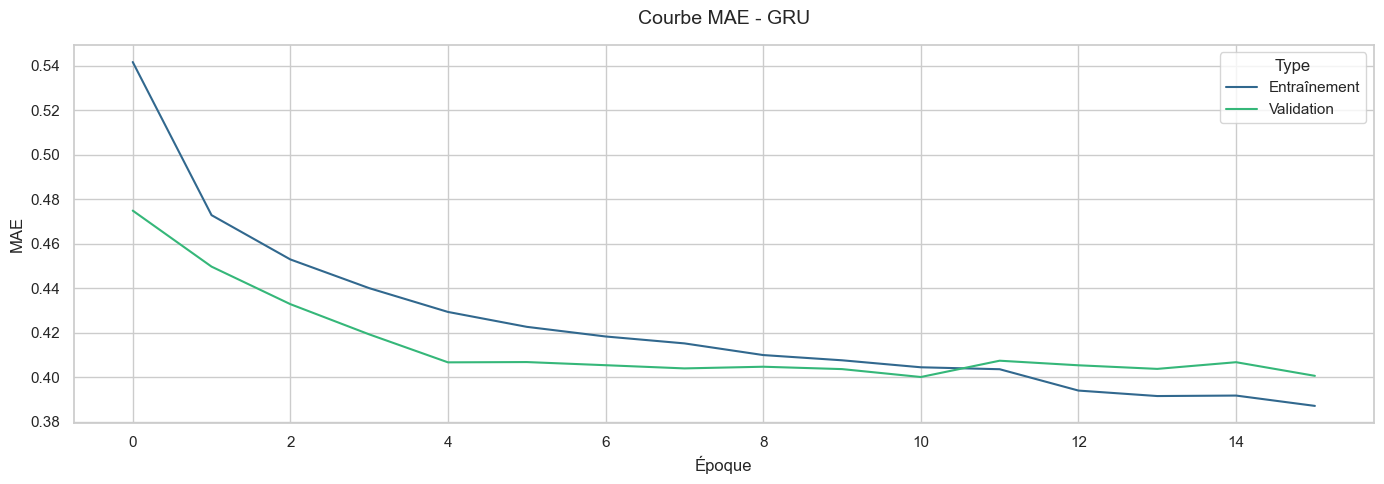

In [10]:
def plot_learning_curves(history, model_name):
    # Conversion de l'historique en DataFrame
    df_history = pd.DataFrame(history.history)
    df_history.index.name = "Epoch"
    df_history = df_history.reset_index()

    # Liste des paires de métriques à tracer
    metrics_list = [("loss", "val_loss", "MSE"), ("mae", "val_mae", "MAE")]

    for train_met, val_met, label in metrics_list:
        # Transformation en format long pour Seaborn
        df_history_melted = df_history.melt(id_vars="Epoch", value_vars=[train_met, val_met],
                                            var_name="Dataset", value_name=label)

        df_history_melted["Dataset"] = df_history_melted["Dataset"].replace({
            train_met: "Entraînement",
            val_met: "Validation"
        })

        sns.lineplot(data=df_history_melted, x="Epoch", y=label, hue="Dataset", palette="viridis")
        plt.title(f"Courbe {label} - {model_name}", fontsize=14, pad=15)
        plt.xlabel("Époque")
        plt.ylabel(label)
        plt.legend(title="Type")
        plt.tight_layout()
        plt.show()

plot_learning_curves(history_simple_rnn, "SimpleRNN")
plot_learning_curves(history_simple_rnn_bidirectional, "SimpleRNN bidirectionnel")
plot_learning_curves(history_lstm, "LSTM")
plot_learning_curves(history_gru, "GRU")

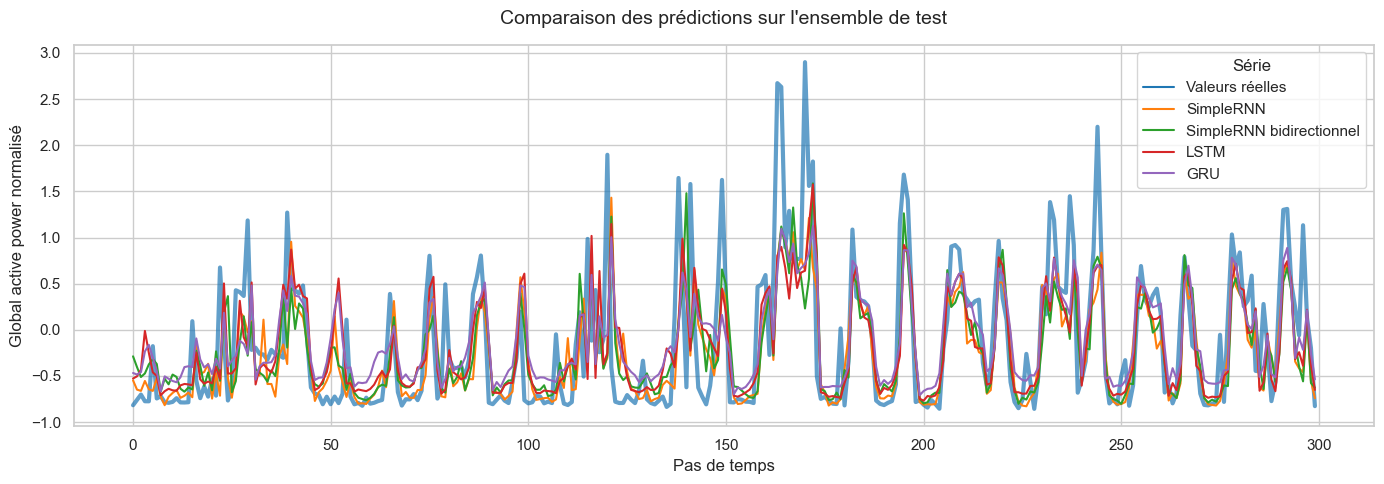

In [11]:
def get_predictions(model, dataset_test):
    y_true = []
    y_pred = []

    for x_batch_test, y_batch_test in dataset_test:
        preds = model.predict(x_batch_test, verbose=0)
        y_true.extend(y_batch_test.numpy())
        y_pred.extend(preds.flatten())

    return np.array(y_true), np.array(y_pred)


y_true_scaled, y_pred_simple_scaled = get_predictions(simple_rnn_baseline, test_ds)
_, y_pred_simple_bidirectional_scaled = get_predictions(simple_rnn_bidirectional, test_ds)

_, y_pred_lstm_scaled = get_predictions(lstm_model, test_ds)
_, y_pred_gru_scaled = get_predictions(gru_model, test_ds)

start, end = 0, 300

plot_data = pd.DataFrame({
    "Pas de temps": range(start, end),
    "Valeurs réelles": y_true_scaled[start:end],
    "SimpleRNN": y_pred_simple_scaled[start:end],
    "SimpleRNN bidirectionnel": y_pred_simple_bidirectional_scaled[start:end],
    "LSTM": y_pred_lstm_scaled[start:end],
    "GRU": y_pred_gru_scaled[start:end]
})

# On transforme le DataFrame au format "Long-form"
df_melted = plot_data.melt(id_vars="Pas de temps", var_name="Série", value_name="Valeur")

ax = sns.lineplot(data=df_melted, x="Pas de temps", y="Valeur", hue="Série", palette="tab10", linewidth=1.5)
plt.title("Comparaison des prédictions sur l'ensemble de test", fontsize=14, pad=15)
plt.xlabel("Pas de temps")
plt.ylabel("Global active power normalisé")
plt.setp(ax.lines[0], linewidth=3, alpha=0.7)

plt.tight_layout()
plt.show()

Le modèle LSTM obtient les meilleures performances sur l'ensemble de test avec une RMSE de 0.491308. Le modèle GRU arrive juste derrière avec une RMSE de 0.491652, ce qui montre que ses performances sont très proches du LSTM. Le SimpleRNN bidirectionnel obtient une RMSE de 0.503333, ce qui améliore les résultats du SimpleRNN classique, qui obtient une RMSE de 0.513873.

Ces résultats sont cohérents avec la théorie : les LSTM et GRU sont mieux adaptés que les SimpleRNN pour traiter des séries temporelles, car ils utilisent des mécanismes de portes permettant de mieux conserver ou oublier les informations au fil du temps. L’ajout d’une couche bidirectionnelle améliore le SimpleRNN, mais ne suffit pas à atteindre les performances du LSTM et du GRU.

### Analyse des courbes d'apprentissage

Les courbes d'apprentissage montrent que les modèles apprennent correctement. Pour chaque modèle, la perte d'entraînement et la perte de validation diminuent progressivement au fil des époques, ce qui indique que les réseaux parviennent à extraire des informations utiles à partir des fenêtres temporelles.

Pour le SimpleRNN, la perte diminue rapidement au début, puis se stabilise progressivement. La courbe de validation suit globalement la même tendance que la courbe d'entraînement, ce qui montre qu'il n'y a pas de surapprentissage important.

Le SimpleRNN bidirectionnel présente de meilleures performances que le SimpleRNN classique. Cela montre que la lecture de la fenêtre temporelle dans les deux sens permet au modèle d'exploiter davantage d'informations internes à la séquence. Le modèle ne lit plus uniquement les observations dans l'ordre chronologique, mais apprend également une représentation de la même fenêtre dans l'ordre inverse.

Le LSTM présente également une diminution régulière de la perte. Il obtient la meilleure performance finale sur l'ensemble de test. Cela peut s'expliquer par sa capacité à mieux mémoriser certaines dépendances temporelles grâce à ses mécanismes de portes.

Le GRU obtient des performances très proches du LSTM. Sa courbe de validation se stabilise également, ce qui montre qu'il généralise correctement. Le GRU constitue donc un bon compromis entre complexité et performance.

Globalement, les courbes ne montrent pas de surapprentissage marqué, car les pertes de validation ne remontent pas fortement pendant que les pertes d'entraînement diminuent. L'utilisation de l'EarlyStopping permet aussi de limiter ce risque.

### Analyse des prédictions

Le graphique des prédictions compare les valeurs réelles de `Global_active_power` avec les prédictions des modèles sur une portion de l'ensemble de test.

On observe que les modèles parviennent globalement à suivre les tendances générales de la consommation électrique. Les phases de faible consommation sont assez bien représentées, et les modèles détectent plusieurs variations importantes.

Cependant, les pics de consommation les plus élevés sont souvent sous-estimés. Cela signifie que les modèles ont tendance à produire des prédictions plus lissées que les valeurs réelles. Ce comportement est fréquent dans les problèmes de régression sur séries temporelles, surtout lorsque les pics sont courts, irréguliers ou difficiles à anticiper uniquement à partir des valeurs précédentes.

Le SimpleRNN bidirectionnel suit globalement mieux les variations que le SimpleRNN classique, ce qui est cohérent avec sa meilleure RMSE. Cependant, il reste moins performant que le LSTM et le GRU.

Le LSTM et le GRU semblent mieux suivre les variations que les variantes basées sur SimpleRNN, ce qui est cohérent avec leurs meilleures performances numériques. Néanmoins, aucun modèle ne prédit parfaitement les pics brusques de consommation.


### Comparaison finale des architectures

Les architectures testées permettent toutes de traiter des données séquentielles, mais elles n'ont pas exactement les mêmes capacités.

Le SimpleRNN constitue notre modèle de base. Il est plus simple, plus léger et plus rapide à entraîner. Cependant, il est généralement moins performant pour apprendre des dépendances temporelles longues, car il peut être limité par le problème de disparition du gradient.

Le SimpleRNN bidirectionnel améliore le SimpleRNN classique. Il lit chaque fenêtre temporelle dans les deux sens, ce qui permet d'exploiter davantage la structure interne de la séquence. Dans notre cas, cela ne constitue pas une fuite de données, car la valeur cible à prédire n'est pas incluse dans la fenêtre d'entrée. Le modèle ne voit donc pas le futur réel, mais seulement les observations passées déjà disponibles dans la fenêtre.

Cette variante reste toutefois plus coûteuse qu'un SimpleRNN classique, car chaque couche récurrente est dupliquée en une direction forward et une direction backward. Elle augmente donc le nombre de paramètres, le temps d'entraînement et potentiellement le risque de surapprentissage.

Le LSTM obtient les meilleurs résultats dans notre expérimentation. Cela s'explique par son mécanisme de portes, qui lui permet de mieux contrôler les informations à retenir, à oublier ou à transmettre dans le temps. Cette propriété est particulièrement utile pour une série temporelle comme la consommation électrique, qui peut dépendre de comportements répétitifs sur plusieurs heures.

Le GRU obtient des résultats très proches du LSTM. Il utilise également des mécanismes de portes, mais avec une structure plus simple. Il possède donc moins de paramètres que le LSTM, tout en gardant de bonnes performances. Dans notre cas, le GRU représente un bon compromis entre performance et complexité.

Le meilleur modèle final est donc le LSTM, car il obtient la RMSE la plus faible sur l'ensemble de test. Toutefois, la différence avec le GRU reste très faible, ce qui montre que les deux architectures sont adaptées à cette tâche.

### Discussion sur l'utilisation de Bidirectional

L'utilisation d'une couche Bidirectional peut être intéressante dans certains problèmes séquentiels, car elle permet au modèle de lire une séquence dans les deux sens : dans l'ordre normal et dans l'ordre inverse.

Dans notre cas, cette approche a été testée sur le modèle SimpleRNN. Le SimpleRNN classique obtient une RMSE de 0.513873, tandis que le SimpleRNN bidirectionnel obtient une RMSE de 0.503333. L'ajout de Bidirectional améliore donc le SimpleRNN.

Cette amélioration montre que la lecture de la fenêtre temporelle dans les deux sens permet au modèle d'exploiter davantage d'informations internes à la séquence. Le modèle peut mieux analyser les relations entre le début, le milieu et la fin de la fenêtre d'entrée.

Cependant, cette amélioration reste limitée. Le SimpleRNN bidirectionnel reste moins performant que le LSTM et le GRU. Cela confirme que les mécanismes de portes des LSTM et GRU sont plus adaptés à la modélisation de dépendances temporelles complexes.

Il faut également rester prudent avec l'utilisation de Bidirectional dans les tâches de prévision temporelle. Dans notre cas, le modèle ne reçoit que les 24 heures précédentes pour prédire la valeur suivante. Il ne voit donc pas la vraie valeur future à prédire. L'utilisation de Bidirectional reste donc acceptable ici, car elle ne fait que relire la fenêtre historique disponible dans les deux sens.

En situation réelle, cette approche reste pertinente uniquement si toute la fenêtre d'entrée est disponible au moment de la prédiction.

### Limites du travail

La première limite concerne le rééchantillonnage horaire. Le dataset original contient des mesures à la minute, mais nous avons choisi de calculer une moyenne par heure afin de réduire le volume de données et de respecter la contrainte de temps d'entraînement. Cette décision permet d'obtenir un entraînement plus rapide, mais elle entraîne aussi une perte d'information sur les variations très courtes.

Une deuxième limite concerne les pics de consommation. Les modèles ont tendance à lisser les prédictions et à sous-estimer certains pics importants. Cela peut s'expliquer par le caractère irrégulier de ces pics, qui sont parfois difficiles à prédire uniquement à partir des 24 heures précédentes.

Une troisième limite est liée au choix de la fenêtre temporelle. Nous avons utilisé une fenêtre de 24 heures, ce qui permet de capturer un cycle journalier. D'autres tailles de fenêtre, comme 48 heures ou 72 heures, pourraient être testées afin d'étudier l'impact de l'historique disponible sur les performances.

Une quatrième limite concerne l'utilisation de Bidirectional. Cette variante augmente le nombre de paramètres du modèle et peut donc augmenter le temps d'entraînement. Elle peut aussi accroître le risque de surapprentissage, surtout si le dataset est trop petit ou si le modèle devient trop complexe.

Enfin, les métriques présentées dans le tableau comparatif sont calculées sur les données normalisées. Elles permettent donc de comparer les modèles entre eux, mais elles sont moins directement interprétables dans l'unité réelle de la variable `Global_active_power`.

## Conclusion

Ce projet nous a permis d'appliquer plusieurs architectures de réseaux de neurones récurrents à un problème de prédiction de série temporelle. Nous avons travaillé sur le dataset de consommation électrique domestique et avons mis en place un pipeline complet comprenant le nettoyage des données, la gestion des valeurs manquantes, le rééchantillonnage horaire, la normalisation, le fenêtrage, l'entraînement et l'évaluation des modèles.

Nous avons comparé plusieurs architectures : SimpleRNN, SimpleRNN bidirectionnel, LSTM et GRU. Les résultats montrent que le LSTM obtient les meilleures performances sur l'ensemble de test, avec la RMSE la plus faible. Le GRU obtient des performances très proches, tandis que le SimpleRNN reste le moins performant.

L'utilisation de Bidirectional améliore le SimpleRNN classique. Le SimpleRNN bidirectionnel obtient une RMSE plus faible que le SimpleRNN classique, ce qui montre que la lecture de la fenêtre temporelle dans les deux sens apporte un gain. Toutefois, ce gain reste limité et ne permet pas de dépasser les architectures LSTM et GRU.

Les visualisations montrent que les modèles suivent correctement la tendance générale de la consommation électrique, mais qu'ils ont plus de difficulté à prédire les pics brusques. Cette limite est cohérente avec la nature du problème, car certains pics de consommation peuvent être irréguliers et difficiles à anticiper.

Ce travail nous a permis d'approfondir plusieurs notions importantes : le traitement des séries temporelles, le fenêtrage, la normalisation sans fuite de données, les différences entre SimpleRNN, SimpleRNN bidirectionnel, LSTM et GRU, ainsi que l'interprétation des métriques de régression comme la MSE, la MAE et la RMSE.